# RC Low-Pass Filter Simulation for stabilizerPi PWM Output

This notebook simulates the first-order RC low-pass filter that sits between
the RP2350 PWM pin (GP15) and the AOM driver modulation input.

**Signal chain modelled:**
1. PID output (0–1) → `aom_linearize()` → drive voltage (0.18–1.25 V)
2. `volts_to_pwm()` → 10-bit PWM level (0–1023)
3. PWM on GP15 at **~146.5 kHz** (150 MHz / 1024)
4. **RC low-pass** → smoothed DC to AOM driver

The PWM edges include realistic ringing (overshoot / undershoot) caused by
parasitic trace inductance and capacitance.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

#%matplotlib widget

## Parameters from firmware (`config.h`)

In [12]:
# ---- Firmware constants (from config.h) ----
PWM_WRAP   = 1023          # 10-bit counter
PWM_CLKDIV = 1.0
SYS_CLK_HZ = 150e6        # RP2350 default
ADC_VREF   = 3.3           # V
PWM_DUTY_VOLTAGE_SCALE = 1.0

PWM_FREQ_HZ = SYS_CLK_HZ / PWM_CLKDIV / (PWM_WRAP + 1)
PWM_PERIOD  = 1.0 / PWM_FREQ_HZ
print(f"PWM frequency : {PWM_FREQ_HZ/1e3:.1f} kHz")
print(f"PWM period    : {PWM_PERIOD*1e6:.2f} \u00b5s")

PWM frequency : 146.5 kHz
PWM period    : 6.83 µs


## AOM linearisation LUT (from `aom_lut.c`)

In [13]:
lut_norm  = np.array([0.000, 0.005, 0.124, 0.291, 0.441, 0.569,
                      0.684, 0.767, 0.841, 0.885, 0.937, 0.988, 1.000])
lut_drive = np.array([0.18,  0.20,  0.30,  0.40,  0.50,  0.60,
                      0.70,  0.80,  0.90,  1.00,  1.10,  1.20,  1.25])

def aom_linearize(normalized_power):
    return np.interp(np.clip(normalized_power, 0, 1), lut_norm, lut_drive)

def volts_to_pwm(v):
    ratio = np.clip((v * PWM_DUTY_VOLTAGE_SCALE) / ADC_VREF, 0, 1)
    return np.round(ratio * PWM_WRAP).astype(int)

## PWM waveform generator with realistic edge ringing

Real CMOS outputs ring on edges due to bond-wire / trace inductance
combined with pad + load capacitance.  We model each edge as a
**multi-cycle damped sinusoidal oscillation** superimposed on the ideal
square wave.

- **Rising edge:** rings above *and below* V_high before settling.
- **Falling edge:** rings below *and above* V_low before settling.

Default parameters (~20 MHz ring frequency, Q ≈ 3) give 3–4 visible
oscillation cycles per edge, consistent with a Pico on a breadboard
with ~5 cm jumper wires (L ≈ 50 nH, C_load ≈ 50 pF).

In [14]:
def generate_pwm_waveform(duty_ratio, n_cycles, dt,
                          v_high=3.3, v_low=0.0,
                          ring_freq=20e6, ring_decay=20e6,
                          overshoot_frac=0.12):
    """
    Generate a PWM waveform with multi-cycle damped-sinusoidal ringing
    on every rising and falling edge.

    Parameters
    ----------
    duty_ratio     : 0–1 fractional duty cycle
    n_cycles       : number of PWM periods to generate
    dt             : simulation time step (s)  — must be << 1/ring_freq
    v_high/v_low   : rail voltages (V)
    ring_freq      : ringing oscillation frequency (Hz, default 20 MHz)
    ring_decay     : exponential decay rate 1/s  (default 20 MHz → ~3–4
                     visible oscillation cycles before the ringing fades)
    overshoot_frac : peak overshoot as fraction of (v_high − v_low)
    """
    total_time = n_cycles * PWM_PERIOD
    t = np.arange(0, total_time, dt)
    n_samples = len(t)

    swing = v_high - v_low
    t_on = duty_ratio * PWM_PERIOD

    phase = (t % PWM_PERIOD) / PWM_PERIOD
    v = np.where(phase < duty_ratio, v_high, v_low)

    ring_window = min(10.0 / max(ring_decay, 1.0), PWM_PERIOD / 2)
    ring_window_samples = int(ring_window / dt) + 1

    dt_ring = np.arange(1, ring_window_samples + 1) * dt
    ring_template = (overshoot_frac * swing
                     * np.exp(-ring_decay * dt_ring)
                     * np.sin(2 * np.pi * ring_freq * dt_ring))

    for cycle in range(n_cycles):
        t0 = cycle * PWM_PERIOD
        for t_edge, sign in [(t0, +1.0), (t0 + t_on, -1.0)]:
            idx_edge = int(round(t_edge / dt))
            i_start = idx_edge + 1
            i_end = min(i_start + ring_window_samples, n_samples)
            length = i_end - i_start
            if length > 0:
                v[i_start:i_end] += sign * ring_template[:length]

    return t, v

## RC filter simulation (time-domain, first-order ODE)

$$V_{out}[n+1] = V_{out}[n] + \frac{\Delta t}{RC}\,(V_{in}[n] - V_{out}[n])$$

In [15]:
def rc_filter(t, v_in, R, C):
    """First-order RC low-pass, forward-Euler integration."""
    tau = R * C
    dt = t[1] - t[0]
    alpha = dt / tau
    v_out = np.zeros_like(v_in)
    v_out[0] = v_in[0]
    for i in range(len(v_in) - 1):
        v_out[i + 1] = v_out[i] + alpha * (v_in[i] - v_out[i])
    return v_out

## Interactive simulation

Use the sliders to pick **R** and **C**, the drive voltage, and the number of
PWM cycles to simulate.  The plot shows:
- **blue** – raw PWM waveform (with edge ringing)
- **orange** – RC-filtered output
- **green dashed** – ideal DC level (duty × 3.3 V)

In [16]:
style = {'description_width': '140px'}
layout = widgets.Layout(width='500px')

w_R = widgets.FloatLogSlider(
    value=1e3, base=10, min=1, max=6, step=0.01,
    description='R (\u03a9)', style=style, layout=layout,
    readout_format='.1f')

w_C = widgets.FloatLogSlider(
    value=100e-9, base=10, min=-10, max=-5, step=0.01,
    description='C (F)', style=style, layout=layout,
    readout_format='.2e')

w_drive = widgets.FloatSlider(
    value=0.60, min=0.18, max=1.25, step=0.01,
    description='Drive voltage (V)', style=style, layout=layout)

w_cycles = widgets.IntSlider(
    value=30, min=5, max=200, step=5,
    description='PWM cycles', style=style, layout=layout)

w_overshoot = widgets.FloatSlider(
    value=12, min=0, max=100, step=1,
    description='Edge overshoot (%)', style=style, layout=layout)

out = widgets.Output()

def run_simulation(change=None):
    R = w_R.value
    C = w_C.value
    drive_v = w_drive.value
    n_cycles = w_cycles.value
    overshoot = w_overshoot.value / 100.0

    pwm_level = volts_to_pwm(drive_v)
    duty = pwm_level / (PWM_WRAP + 1)

    tau = R * C
    f_cutoff = 1.0 / (2 * np.pi * tau)

    samples_per_cycle = 2000
    dt = PWM_PERIOD / samples_per_cycle

    t, v_pwm = generate_pwm_waveform(
        duty, n_cycles, dt, overshoot_frac=overshoot)
    v_out = rc_filter(t, v_pwm, R, C)

    ideal_dc = duty * ADC_VREF

    ripple_last = v_out[-samples_per_cycle:]
    ripple_pp = ripple_last.max() - ripple_last.min()

    with out:
        out.clear_output(wait=True)

        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

        t_us = t * 1e6

        axes[0].plot(t_us, v_pwm, linewidth=0.4, alpha=0.7, label='PWM (raw)')
        axes[0].plot(t_us, v_out, linewidth=1.5, label='RC output')
        axes[0].axhline(ideal_dc, color='green', ls='--', lw=1,
                        label=f'Ideal DC = {ideal_dc:.3f} V')
        axes[0].set_ylabel('Voltage (V)')
        axes[0].set_title(
            f'R = {R:.0f} \u03a9,  C = {C*1e9:.1f} nF,  '
            f'f_c = {f_cutoff/1e3:.2f} kHz,  '
            f'\u03c4 = {tau*1e6:.1f} \u00b5s\n'
            f'Drive = {drive_v:.2f} V \u2192 PWM level {pwm_level}/{PWM_WRAP} '
            f'({duty*100:.1f}%)   |   '
            f'Ripple (last cycle) = {ripple_pp*1e3:.1f} mV p-p')
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(t_us, (v_out - ideal_dc) * 1e3, linewidth=0.8,
                     color='tab:red')
        axes[1].set_ylabel('Ripple (mV)')
        axes[1].set_xlabel('Time (\u00b5s)')
        axes[1].axhline(0, color='gray', ls='-', lw=0.5)
        axes[1].grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()

btn = widgets.Button(description='Run Simulation', button_style='primary',
                     layout=widgets.Layout(width='200px', height='36px'))
btn.on_click(run_simulation)

ui = widgets.VBox([
    widgets.HTML('<h3>Pick R and C for the low-pass filter</h3>'),
    w_R, w_C, w_drive, w_cycles, w_overshoot,
    widgets.HTML(
        '<i>README default: R = 1 k\u03a9, C = 100 nF \u2192 f<sub>c</sub> \u2248 1.6 kHz</i>'),
    btn,
    out
])

display(ui)
run_simulation()

## Frequency-domain view

Plot the Bode magnitude of the chosen RC filter alongside the PWM
fundamental and first few harmonics to visualise ripple attenuation.

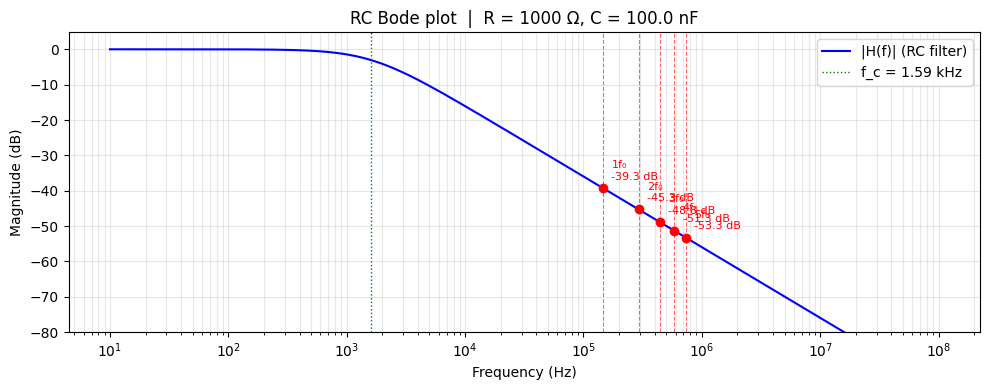

In [17]:
def plot_bode(change=None):
    R = w_R.value
    C = w_C.value
    tau = R * C
    f_c = 1 / (2 * np.pi * tau)

    f = np.logspace(1, 8, 2000)
    H_mag_dB = -10 * np.log10(1 + (f / f_c) ** 2)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(f, H_mag_dB, 'b-', lw=1.5, label='|H(f)| (RC filter)')

    for n in range(1, 6):
        f_n = n * PWM_FREQ_HZ
        atten = -10 * np.log10(1 + (f_n / f_c) ** 2)
        ax.axvline(f_n, color='red', ls='--', lw=0.8, alpha=0.6)
        ax.plot(f_n, atten, 'ro', ms=6)
        ax.annotate(f'{n}f\u2080\n{atten:.1f} dB',
                    (f_n, atten), textcoords='offset points',
                    xytext=(6, 6), fontsize=8, color='red')

    ax.axvline(f_c, color='green', ls=':', lw=1, label=f'f_c = {f_c/1e3:.2f} kHz')
    ax.set_xscale('log')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'RC Bode plot  |  R = {R:.0f} \u03a9, C = {C*1e9:.1f} nF')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(bottom=-80)
    fig.tight_layout()
    plt.show()

plot_bode()

## Step-response comparison

Shows how quickly the filtered output settles when the drive voltage
steps from the LUT minimum (0.18 V) to a target value.
Useful for evaluating whether your RC time constant is compatible with
the 1 kHz control-loop bandwidth.

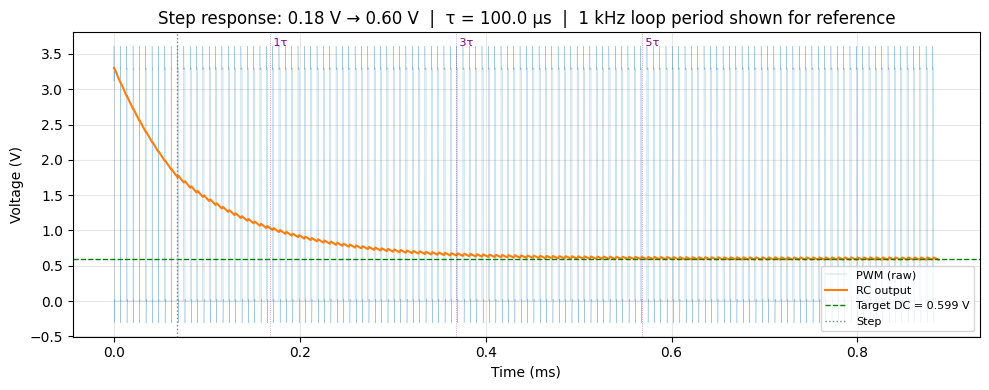

In [18]:
def plot_step_response(change=None):
    R = w_R.value
    C = w_C.value
    drive_v = w_drive.value
    overshoot = w_overshoot.value / 100.0

    v_start = 0.18
    v_end = drive_v

    pwm_start = volts_to_pwm(v_start)
    pwm_end   = volts_to_pwm(v_end)
    duty_start = pwm_start / (PWM_WRAP + 1)
    duty_end   = pwm_end / (PWM_WRAP + 1)

    n_settle = 120
    n_pre = 10
    n_total = n_pre + n_settle
    samples_per_cycle = 2000
    dt = PWM_PERIOD / samples_per_cycle

    t_pre, v_pre = generate_pwm_waveform(
        duty_start, n_pre, dt, overshoot_frac=overshoot)
    t_post, v_post = generate_pwm_waveform(
        duty_end, n_settle, dt, overshoot_frac=overshoot)

    t_full = np.concatenate([t_pre, t_pre[-1] + dt + t_post])
    v_full = np.concatenate([v_pre, v_post])

    v_out = rc_filter(t_full, v_full, R, C)

    ideal_start = duty_start * ADC_VREF
    ideal_end   = duty_end * ADC_VREF
    tau = R * C

    fig, ax = plt.subplots(figsize=(10, 4))
    t_ms = t_full * 1e3
    ax.plot(t_ms, v_full, lw=0.3, alpha=0.5, label='PWM (raw)')
    ax.plot(t_ms, v_out, lw=1.5, label='RC output')
    ax.axhline(ideal_end, color='green', ls='--', lw=1,
               label=f'Target DC = {ideal_end:.3f} V')
    t_step_ms = t_pre[-1] * 1e3
    ax.axvline(t_step_ms, color='gray', ls=':', lw=1, label='Step')

    for n_tau in [1, 3, 5]:
        t_mark = t_step_ms + n_tau * tau * 1e3
        if t_mark < t_ms[-1]:
            ax.axvline(t_mark, color='purple', ls=':', lw=0.6, alpha=0.5)
            ax.text(t_mark, ax.get_ylim()[1] * 0.95,
                    f' {n_tau}\u03c4', fontsize=8, color='purple')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(
        f'Step response: {v_start:.2f} V \u2192 {v_end:.2f} V  |  '
        f'\u03c4 = {tau*1e6:.1f} \u00b5s  |  '
        f'1 kHz loop period shown for reference')
    loop_period_ms = 1.0
    for k in range(1, int(t_ms[-1] / loop_period_ms) + 1):
        ax.axvline(k * loop_period_ms, color='orange', ls='-',
                   lw=0.4, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

plot_step_response()